# Week 5 — Retrieval-Augmented Generation (RAG): Build + Evaluate
### A Mathematical and Experimental Introduction

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/week5_rag_math.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

This notebook combines **two 50-minute lectures** into a single Colab document.
It blends formal equations, visual intuition, and small code experiments.

We will:
1. Define RAG mathematically
2. Implement key components in Python (chunking, embedding, retrieval)
3. Visualize vector similarity
4. Compute evaluation metrics (Recall@k, Hallucination Rate, Faithfulness)


In [1]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.append('/content/main')
from course_utils import lab5_setup
lab5_setup()
print('✅ Environment ready!')

Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
✅ Environment ready!


## 🧠 Lecture 1 — How RAG Works

Retrieval-Augmented Generation extends LLMs with **retrieval + evidence grounding**.

A standard LLM models:
$$ P_\theta(y \mid x) $$
But this fails when \(x\) refers to knowledge not in training data.

RAG adds external retrieval:
$$ P(y \mid x, D) = P_\theta(y \mid x, R_k(x, D)) $$

where $R_k(x, D)$ is the top-*k* retrieved chunks from document corpus $D$.

### 📄 Step 1: Chunking Documents

Documents must be broken into smaller *chunks* so they can fit into the model’s context window:
$$ D = \bigcup_i c_i, \quad |c_i| < L_{max} $$

In [2]:
# @title Example: Simple Text Chunking
def chunk_text(text, size=50, overlap=15):
    chunks = []
    for i in range(0, len(text), size - overlap):
        chunks.append(text[i:i+size])
    return chunks

sample = ('The Eiffel Tower was constructed in Paris, France, from 1887 to 1889. '
          'It was named after Gustave Eiffel and has become a symbol of France.')
for c in chunk_text(sample):
    print('-', c)

- The Eiffel Tower was constructed in Paris, France,
-  Paris, France, from 1887 to 1889. It was named af
- It was named after Gustave Eiffel and has become a
- nd has become a symbol of France.


### 🔢 Step 2: Embedding and Retrieval

Each chunk is represented as a vector $v_i = f(c_i) \in \mathbb{R}^d$, and the query as $q = f(x)$.

Similarity is computed via **cosine similarity**:
$$ \text{sim}(q, v_i) = \frac{q \cdot v_i}{\|q\| \|v_i\|} $$

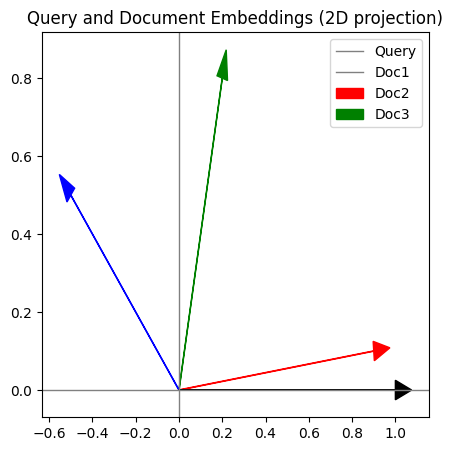

Doc1 similarity = 0.99
Doc2 similarity = 0.24
Doc3 similarity = -0.71


In [3]:
# @title Visualize Vector Similarity
import numpy as np
from numpy.linalg import norm
def cosine_similarity(a,b):
    return np.dot(a,b)/(norm(a)*norm(b))

query = np.array([1,0])
docs = [np.array([0.9, 0.1]), np.array([0.2,0.8]), np.array([-0.5,0.5])]
sims = [cosine_similarity(query, d) for d in docs]
plt.figure(figsize=(5,5))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
colors=['r','g','b']
for d,c in zip(docs,colors):
    plt.arrow(0,0,d[0],d[1],head_width=0.05, color=c)
plt.arrow(0,0,query[0],query[1],color='k',head_width=0.05,label='query')
plt.legend(['Query','Doc1','Doc2','Doc3'])
plt.title('Query and Document Embeddings (2D projection)')
plt.show()
for i,s in enumerate(sims):
    print(f'Doc{i+1} similarity = {s:.2f}')

### 🧩 Step 3: Prompt Assembly and Grounded Generation

After retrieving the top-k chunks, we construct the final model input:

$$
\text{Prompt}(x, R_k) = \texttt{System: You are a helpful assistant.} $$

$$ \texttt{Context:} [c_{i_1}] [c_{i_2}] \dots [c_{i_k}] $$

$$ \texttt{User: } x $$

Then the LLM generates:
$$ y = \text{LLM}(\text{Prompt}(x, R_k(x,D))) $$

In [4]:
# @title Example: Prompt Assembly
query = 'Who built the Eiffel Tower?'
retrieved = ['The Eiffel Tower was designed by engineer Gustave Eiffel.',
             'Construction occurred between 1887 and 1889 in Paris.']
prompt = f'System: You are a helpful assistant.\nContext:\n'
for c in retrieved:
    prompt += f'<doc>{c}</doc>\n'
prompt += f'User: {query}\nAnswer:'
print(prompt)

System: You are a helpful assistant.
Context:
<doc>The Eiffel Tower was designed by engineer Gustave Eiffel.</doc>
<doc>Construction occurred between 1887 and 1889 in Paris.</doc>
User: Who built the Eiffel Tower?
Answer:


## 📗 Lecture 2 — Evaluating and Improving RAG

RAG evaluation focuses on two dimensions:
1. **Retrieval quality** — do we fetch relevant evidence?
2. **Generation faithfulness** — does the model stay grounded in that evidence?

---

### 📊 Retrieval Metrics: Recall@k and Precision@k

Given ground-truth relevant chunks \(G(x)\) and retrieved \(R_k(x)\):
$$ \text{Recall@k} = \frac{|G(x) \cap R_k(x)|}{|G(x)|} $$
$$ \text{Precision@k} = \frac{|G(x) \cap R_k(x)|}{|R_k(x)|} $$

In [5]:
# @title Compute Recall@k Example
true_relevant = {'doc1','doc2','doc3'}
retrieved = ['doc1','doc4','doc2']
recall = len(set(true_relevant)&set(retrieved))/len(true_relevant)
precision = len(set(true_relevant)&set(retrieved))/len(retrieved)
print(f'Recall@3 = {recall:.2f}, Precision@3 = {precision:.2f}')

Recall@3 = 0.67, Precision@3 = 0.67


### 🔬 Measuring Hallucination Rate

Let generated answer contain \(N\) statements \(\{s_1, s_2, \dots, s_N\}\).

Each statement has an indicator:
$$
h_i = \begin{cases}
1, & \text{if } s_i \text{ is unsupported by } R_k(x,D) \\
0, & \text{if } s_i \text{ is supported}
\end{cases}
$$

Then:
$$ H = \frac{1}{N}\sum_{i=1}^N h_i $$

**Manual computation example:**

In [ ]:
# @title Manual Hallucination Computation
claims = ['The Eiffel Tower is in Paris.', 'It was built in Rome.', 'It opened in 1889.']
supported = [True, False, True]
h = [0 if s else 1 for s in supported]
H = sum(h)/len(h)
print(f'Hallucination Rate H = {H:.2f}')

### 🤖 Automated Approximation

Approximate hallucination by embedding similarity between each claim \(s_i\) and retrieved chunks:
$$ \text{support}(s_i) = \max_{c_j \in R_k} \text{sim}(f(s_i), f(c_j)) $$
$$ h_i = \begin{cases} 1, & \text{if } \text{support}(s_i) < \tau \\ 0, & \text{otherwise} \end{cases} $$

### 📈 Tradeoffs Between Chunk Size, k, and Hallucination

Generally:
- Increasing chunk size → fewer chunks → lower recall but richer context.
- Increasing k → more chunks retrieved → higher recall but higher token cost.

Let's visualize hypothetical tradeoffs.

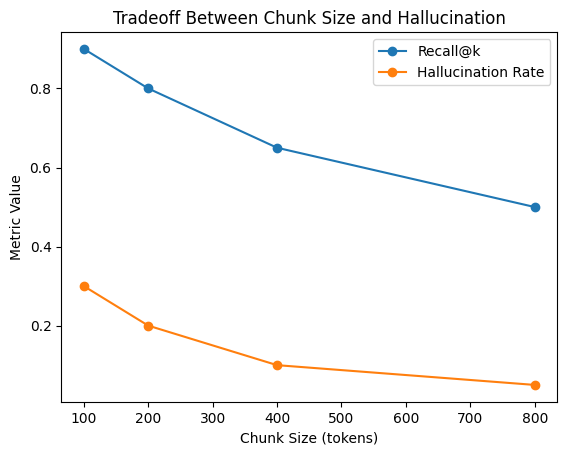

In [6]:
# @title Visualization: Recall vs Hallucination Tradeoff
chunk_sizes = [100,200,400,800]
recall = [0.9,0.8,0.65,0.5]
halluc = [0.3,0.2,0.1,0.05]
plt.plot(chunk_sizes, recall, 'o-', label='Recall@k')
plt.plot(chunk_sizes, halluc, 'o-', label='Hallucination Rate')
plt.xlabel('Chunk Size (tokens)')
plt.ylabel('Metric Value')
plt.title('Tradeoff Between Chunk Size and Hallucination')
plt.legend()
plt.show()

## 🧩 Summary

| Concept | Formula | Meaning |
|----------|----------|----------|
| **Embedding** | $v_i = f(c_i)$ | Text → vector representation |
| **Similarity** | $\frac{q \cdot v_i}{\|q\|\|v_i\|}$ | Semantic closeness |
| **Retrieval** | $R_k = \text{Top}_k(\text{sim}(q,v_i))$ | Find relevant chunks |
| **Prompt Assembly** | $\text{Prompt}(x,R_k)$ | Merge evidence + query |
| **Generation** | $y = \text{LLM}(\text{Prompt})$ | Produce grounded answer |
| **Recall@k** | $\frac{|G\cap R_k|}{|G|}$ | Retrieval completeness |
| **Hallucination Rate** | $\frac{1}{N}\sum h_i$ | Unsupported claims fraction |
| **Faithfulness** | $1-H$ | Grounded correctness |

In **Lab L5**, you will implement these ideas in code — measuring recall@k and hallucination rate empirically.